Q1

In [ ]:
import pandas
names = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
'chlorides', 'free sulfur dioxide', 'total sulfur', 'density', 'ph', 'suplates', 'alcohol',
'quality']
dataset = pandas.read_csv('winequality-s.csv', names=names)

dataset.shape

(2517, 12)

In [ ]:
dataset.head(5)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur,density,ph,suplates,alcohol,quality
0,8.1,0.27,0.41,1.45,0.033,11.0,63.0,0.9908,2.99,0.56,12.0,0
1,8.6,0.23,0.40,4.20,0.035,17.0,109.0,0.9947,3.14,0.53,9.7,0
2,7.9,0.18,0.37,1.20,0.040,16.0,75.0,0.9920,3.18,0.63,10.8,0
3,8.3,0.42,0.62,19.25,0.040,41.0,172.0,1.0002,2.98,0.67,9.7,0
4,6.5,0.31,0.14,7.50,0.044,34.0,133.0,0.9955,3.22,0.50,9.5,0


In [ ]:
dataset.tail(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur,density,ph,suplates,alcohol,quality
2512,9.1,0.27,0.45,10.6,0.035,28.0,124.0,0.99700,3.20,0.46,10.4,1
2513,6.6,0.36,0.29,1.6,0.021,24.0,85.0,0.98965,3.41,0.61,12.4,1
2514,7.4,0.24,0.36,2.0,0.031,27.0,139.0,0.99055,3.28,0.48,12.5,1
2515,6.9,0.36,0.34,4.2,0.018,57.0,119.0,0.98980,3.28,0.36,12.7,1
2516,7.1,0.26,0.49,2.2,0.032,31.0,113.0,0.99030,3.37,0.42,12.9,1


In [ ]:
dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur,density,ph,suplates,alcohol,quality
count,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000
mean,6.846027,0.286571,0.332769,6.461760,0.045909,35.639650,140.098530,0.994062,3.188331,0.489758,10.485683,0.421136
std,0.816222,0.099243,0.119251,5.022289,0.022411,16.478441,41.666216,0.002994,0.149700,0.114499,1.307030,0.493839
min,3.900000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.790000,0.220000,8.000000,0.000000
25%,6.300000,0.220000,0.260000,1.800000,0.035000,24.000000,111.000000,0.991720,3.090000,0.410000,9.400000,0.000000
50%,6.800000,0.280000,0.320000,5.200000,0.043000,34.000000,136.000000,0.993800,3.170000,0.470000,10.200000,0.000000
75%,7.300000,0.330000,0.390000,10.050000,0.050000,46.000000,169.000000,0.996300,3.280000,0.540000,11.400000,1.000000
max,10.300000,0.905000,1.000000,23.500000,0.346000,131.000000,344.000000,1.002410,3.820000,1.080000,14.200000,1.000000


In [ ]:
dataset.quality.value_counts()

,count
quality,
0,1457
1,1060


Q2

In [ ]:
import numpy as np
np.random.seed(0)
perm = np.random.permutation(2517)
x = dataset.iloc[:,0:11].values
y = dataset.iloc[:,11].values

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
# Useful module for dealing with the Gaussian density
from scipy.stats import norm, multivariate_normal
# installing packages for interactive graphs
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import interact, interactive, fixed, interact_manual, IntSlider

In [ ]:
@interact_manual( feature=IntSlider(min=0, max=10, step=1),
label=IntSlider(min=0,max=1,step=1))
def density_plot(feature, label):
  plt.hist(x[y==label,feature], density=True)
  #
  mu = np.mean(x[y==label,feature]) # mean
  var = np.var(x[y==label,feature]) # variance
  std = np.sqrt(var) # standard deviation

  x_axis = np.linspace(mu - 3*std, mu + 3*std, 1000)
  plt.plot(x_axis, norm.pdf(x_axis,mu,std), 'r', lw=2)
  plt.title("Quality "+str(label) )
  plt.xlabel(names[feature], fontsize=14, color='red')
  plt.ylabel('Density', fontsize=14, color='red')
  plt.show()

interactive(children=(IntSlider(value=0, description='feature', max=10), IntSlider(value=0, description='label…

In [ ]:
import numpy as np
np.random.seed(0)
perm = np.random.permutation(2517)
x = dataset.iloc[:,0:11].values
y = dataset.iloc[:,11].values

import matplotlib
import matplotlib.pyplot as plt
# Useful module for dealing with the Gaussian density
from scipy.stats import norm, multivariate_normal
# installing packages for interactive graphs
import numpy as np
np.random.seed(0)
perm = np.random.permutation(2517)
x = dataset.iloc[:,0:11].values
y = dataset.iloc[:,11].values

import matplotlib
import matplotlib.pyplot as plt
# Useful module for dealing with the Gaussian density
from scipy.stats import norm, multivariate_normal
# installing packages for interactive graphs
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import interact, interactive, fixed, interact_manual, IntSlider

@interact_manual( feature=IntSlider(min=0, max=10, step=1),
label=IntSlider(min=0,max=1,step=1))
def density_plot(feature, label):
    plt.hist(x[y==label,feature], density=True)
    #
    mu = np.mean(x[y==label,feature]) # mean
    var = np.var(x[y==label,feature]) # variance
    std = np.sqrt(var) # standard deviation
    #
    x_axis = np.linspace(mu - 3*std, mu + 3*std, 1000)
    plt.plot(x_axis, norm.pdf(x_axis,mu,std), 'r', lw=2)
    plt.title("Quality "+str(label) )
    plt.xlabel(names[feature], fontsize=14, color='red')
    plt.ylabel('Density', fontsize=14, color='red')
    plt.show()

def fit_generative_model(x,y,feature):
    k = 2 # number of classes
    mu = np.zeros(k) # list of means
    var = np.zeros(k) # list of variances
    pi = np.zeros(k) # list of class weights
    # Initialize classIndex to 0
    classIndex = 0
    for label in [0,1]:
        indices = (y==label)
        mu[label] = np.mean(x[indices,feature])
        var[label] = np.var(x[indices,feature])
        pi[label] = float(sum(indices))/float(len(y))
        classIndex+=1 # Increment classIndex within the loop
    # Removed the extra return statement. You only need to return mu, var, pi
    return mu, var, pi

@interact_manual( feature=IntSlider(0,0,10) )
def show_densities(feature):
    mu, var, pi = fit_generative_model(x, y, feature)
    colors = ['r', 'g']
    for classIndex in [0,1]:
        m = mu[classIndex]
        s = np.sqrt(var[classIndex])
        x_axis = np.linspace(m - 3*s, m+3*s, 1000)
        plt.plot(x_axis, norm.pdf(x_axis,m,s), colors[classIndex], label="class " +
        str(classIndex))
        plt.xlabel(names[feature], fontsize=14, color='red')
        plt.ylabel('Density', fontsize=14, color='red')
    plt.legend()
    plt.show()

interactive(children=(IntSlider(value=0, description='feature', max=10), IntSlider(value=0, description='label…

interactive(children=(IntSlider(value=0, description='feature', max=10), Button(description='Run Interact', st…

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define the size of the validation set and random seed
val_size = 0.2
seed = 7

# Split the dataset into training and validation sets
xtrain, xval, ytrain, yval = train_test_split(x, y, test_size=val_size, random_state=seed)

# Check the shapes of the resulting datasets
print("Training feature set shape:", xtrain.shape)
print("Validation feature set shape:", xval.shape)
print("Training label set shape:", ytrain.shape)
print("Validation label set shape:", yval.shape)

# Initialize the StandardScaler
sc_x = StandardScaler()

# Fit and transform the training data
xtrains = sc_x.fit_transform(xtrain)

# Transform the validation data
xvals = sc_x.transform(xval)

# Check the shapes of the normalized datasets
print("Normalized training feature set shape:", xtrains.shape)
print("Normalized validation feature set shape:", xvals.shape)

Training feature set shape: (2013, 11)
Validation feature set shape: (504, 11)
Training label set shape: (2013,)
Validation label set shape: (504,)
Normalized training feature set shape: (2013, 11)
Normalized validation feature set shape: (504, 11)


Q3

1: 0.875802 (0.008383)
3: 0.859908 (0.012053)
5: 0.853450 (0.017093)
7: 0.846990 (0.012285)
9: 0.844502 (0.010269)


<ipython-input-48-961399a687ed>:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultskNN, labels=nameskNN)


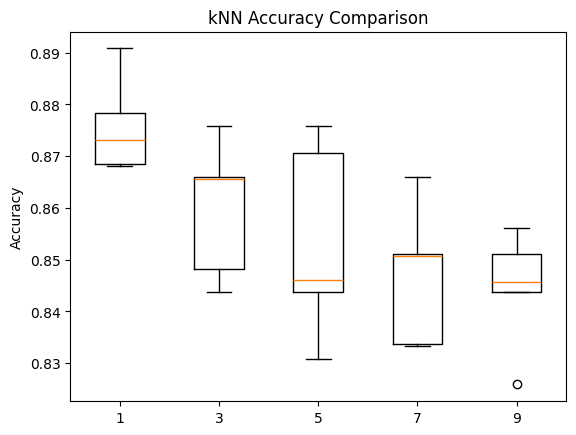

Accuracy on validation set: 0.878968253968254
Confusion Matrix:
 [[249  36]
 [ 25 194]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn import metrics
import matplotlib.pyplot as plt

# Define different k values to test
modelskNN = []
modelskNN.append(('1', KNeighborsClassifier(n_neighbors=1)))
modelskNN.append(('3', KNeighborsClassifier(n_neighbors=3)))
modelskNN.append(('5', KNeighborsClassifier(n_neighbors=5)))
modelskNN.append(('7', KNeighborsClassifier(n_neighbors=7)))
modelskNN.append(('9', KNeighborsClassifier(n_neighbors=9)))

# Initialize lists to store results
resultskNN = []
nameskNN = []

# Set up cross-validation
kfold = StratifiedKFold(n_splits=5)

for name, model in modelskNN:
  cv_results = cross_val_score(model, xtrains, ytrain, cv=kfold, scoring='accuracy')
  resultskNN.append(cv_results)
  nameskNN.append(name)
  print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

# Compare algorithms using boxplot
plt.boxplot(resultskNN, labels=nameskNN)
plt.title('kNN Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

# Assuming J is the optimal number of neighbors found
J = 1  # Replace with the optimal k value you found

# Initialize and fit the kNN model
kNN = KNeighborsClassifier(n_neighbors=J)
kNN.fit(xtrains, ytrain)

# Make predictions on the validation set
predictions = kNN.predict(xvals)

# Calculate and print accuracy
accuracy = metrics.accuracy_score(yval, predictions)
print('Accuracy on validation set:', accuracy)

# Print confusion matrix
conf_matrix = metrics.confusion_matrix(yval, predictions)
print('Confusion Matrix:\n', conf_matrix)

1: 0.875802 (0.008383)
3: 0.859908 (0.012053)
5: 0.853450 (0.017093)
7: 0.846990 (0.012285)
9: 0.844502 (0.010269)


<ipython-input-52-3ff7006c13f4>:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultskNN, labels=nameskNN)


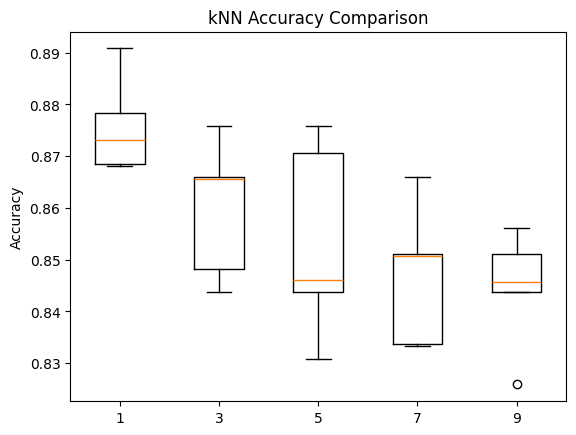

Accuracy on validation set: 0.878968253968254
Confusion Matrix:
 [[249  36]
 [ 25 194]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Define different k values to test
modelskNN = []
modelskNN.append(('1', KNeighborsClassifier(n_neighbors=1)))
modelskNN.append(('3', KNeighborsClassifier(n_neighbors=3)))
modelskNN.append(('5', KNeighborsClassifier(n_neighbors=5)))
modelskNN.append(('7', KNeighborsClassifier(n_neighbors=7)))
modelskNN.append(('9', KNeighborsClassifier(n_neighbors=9)))

# Initialize lists to store results
resultskNN = []
nameskNN = []

# Set up cross-validation
kfold = StratifiedKFold(n_splits=5)

# Normalize the features
scaler = StandardScaler()
xtrains_normalized = scaler.fit_transform(xtrains)  # Normalize training features
xvals_normalized = scaler.transform(xvals)  # Normalize validation features

for name, model in modelskNN:
    cv_results = cross_val_score(model, xtrains_normalized, ytrain, cv=kfold, scoring='accuracy')
    resultskNN.append(cv_results)
    nameskNN.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

# Compare algorithms using boxplot
plt.boxplot(resultskNN, labels=nameskNN)
plt.title('kNN Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

# Assuming J is the optimal number of neighbors found
J = 1  # Replace with the optimal k value you found

# Initialize and fit the kNN model with normalization
kNN = KNeighborsClassifier(n_neighbors=J)
kNN.fit(xtrains_normalized, ytrain)

# Make predictions on the validation set with normalization
predictions = kNN.predict(xvals_normalized)

# Calculate and print accuracy
accuracy = metrics.accuracy_score(yval, predictions)
print('Accuracy on validation set:', accuracy)

# Print confusion matrix
conf_matrix = metrics.confusion_matrix(yval, predictions)
print('Confusion Matrix:\n', conf_matrix)

1: Mean Accuracy (No Norm): 0.875802, Std Dev (No Norm): 0.008383
3: Mean Accuracy (No Norm): 0.859908, Std Dev (No Norm): 0.012053
5: Mean Accuracy (No Norm): 0.853450, Std Dev (No Norm): 0.017093
7: Mean Accuracy (No Norm): 0.846990, Std Dev (No Norm): 0.012285
9: Mean Accuracy (No Norm): 0.844502, Std Dev (No Norm): 0.010269
1: Mean Accuracy (With Norm): 0.875802, Std Dev (With Norm): 0.008383
3: Mean Accuracy (With Norm): 0.859908, Std Dev (With Norm): 0.012053
5: Mean Accuracy (With Norm): 0.853450, Std Dev (With Norm): 0.017093
7: Mean Accuracy (With Norm): 0.846990, Std Dev (With Norm): 0.012285
9: Mean Accuracy (With Norm): 0.844502, Std Dev (With Norm): 0.010269


<ipython-input-51-45b41ca31635>:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultskNN_no_norm + resultskNN_with_norm,


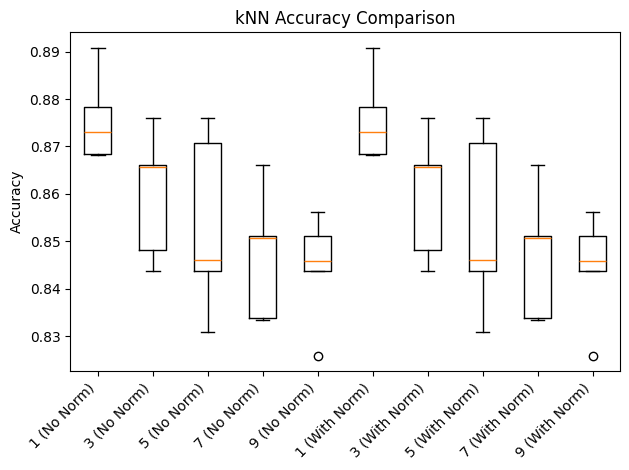

Accuracy on validation set (No Norm): 0.8571428571428571
Accuracy on validation set (With Norm): 0.8571428571428571
Confusion Matrix (No Norm):
 [[247  38]
 [ 34 185]]
Confusion Matrix (With Norm):
 [[247  38]
 [ 34 185]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Assume xtrains and ytrain are defined

# Normalize the features
scaler = StandardScaler()
xtrains_normalized = scaler.fit_transform(xtrains)  # Normalize training features
xvals_normalized = scaler.transform(xvals)  # Normalize validation features

# Define different k values to test
modelskNN = []
modelskNN.append(('1', KNeighborsClassifier(n_neighbors=1)))
modelskNN.append(('3', KNeighborsClassifier(n_neighbors=3)))
modelskNN.append(('5', KNeighborsClassifier(n_neighbors=5)))
modelskNN.append(('7', KNeighborsClassifier(n_neighbors=7)))
modelskNN.append(('9', KNeighborsClassifier(n_neighbors=9)))

# Initialize lists to store results
resultskNN_no_norm = []
resultskNN_with_norm = []
nameskNN = []

# Set up cross-validation
kfold = StratifiedKFold(n_splits=5)

# Perform cross-validation for models without normalization
for name, model in modelskNN:
    cv_results_no_norm = cross_val_score(model, xtrains, ytrain, cv=kfold, scoring='accuracy')
    resultskNN_no_norm.append(cv_results_no_norm)
    nameskNN.append(f"{name} (No Norm)")

    mean_accuracy_no_norm = cv_results_no_norm.mean()
    std_accuracy_no_norm = cv_results_no_norm.std()
    print('%s: Mean Accuracy (No Norm): %f, Std Dev (No Norm): %f' % (name, mean_accuracy_no_norm, std_accuracy_no_norm))

# Perform cross-validation for models with normalization
for name, model in modelskNN:
    cv_results_with_norm = cross_val_score(model, xtrains_normalized, ytrain, cv=kfold, scoring='accuracy')
    resultskNN_with_norm.append(cv_results_with_norm)
    nameskNN.append(f"{name} (With Norm)")

    mean_accuracy_with_norm = cv_results_with_norm.mean()
    std_accuracy_with_norm = cv_results_with_norm.std()
    print('%s: Mean Accuracy (With Norm): %f, Std Dev (With Norm): %f' % (name, mean_accuracy_with_norm, std_accuracy_with_norm))

# Compare algorithms using boxplot
plt.boxplot(resultskNN_no_norm + resultskNN_with_norm,
            labels=nameskNN)  # Concatenate lists to get a single list of arrays
plt.title('kNN Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

# Assuming J is the optimal number of neighbors found
J = 5  # Replace with the optimal k value you found

# Initialize and fit the kNN model with the optimal k (without normalization)
kNN = KNeighborsClassifier(n_neighbors=J)
kNN.fit(xtrains, ytrain)

# Make predictions on the validation set (without normalization)
predictions = kNN.predict(xvals)

# Calculate and print accuracy
accuracy = metrics.accuracy_score(yval, predictions)
print('Accuracy on validation set (No Norm):', accuracy)

# Initialize and fit the kNN model with normalization
kNN_normalized = KNeighborsClassifier(n_neighbors=J)
kNN_normalized.fit(xtrains_normalized, ytrain)

# Make predictions on the validation set (with normalization)
predictions_normalized = kNN_normalized.predict(xvals_normalized)

# Calculate and print accuracy
accuracy_normalized = metrics.accuracy_score(yval, predictions_normalized)
print('Accuracy on validation set (With Norm):', accuracy_normalized)

# Print confusion matrix for both cases
conf_matrix_no_norm = metrics.confusion_matrix(yval, predictions)
print('Confusion Matrix (No Norm):\n', conf_matrix_no_norm)

conf_matrix_with_norm = metrics.confusion_matrix(yval, predictions_normalized)
print('Confusion Matrix (With Norm):\n', conf_matrix_with_norm)

Q4

Logistic Regression: Mean Accuracy: 0.815192, Standard Deviation: 0.015948
1-degree Polynomial: Mean Accuracy: 0.815192 (0.015948)
2-degree Polynomial: Mean Accuracy: 0.855935 (0.003205)
3-degree Polynomial: Mean Accuracy: 0.863880 (0.012742)
4-degree Polynomial: Mean Accuracy: 0.865373 (0.003724)
Accuracy on validation set with best polynomial degree (2): 0.841270
Confusion Matrix:
 [[243  42]
 [ 38 181]]


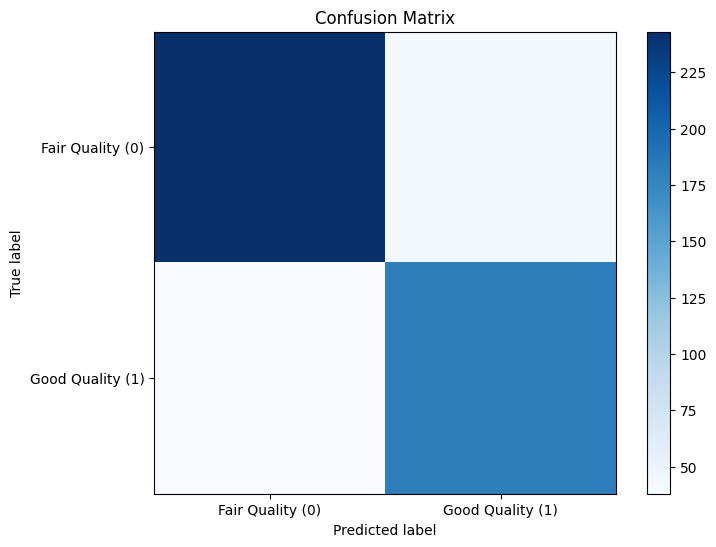

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Initialize the Logistic Regression model
LR = LogisticRegression(max_iter=1000)

# Set up cross-validation
kfold = StratifiedKFold(n_splits=5)

# Perform cross-validation
cv_results = cross_val_score(LR, xtrains, ytrain, cv=kfold, scoring='accuracy')

# Print the results
print('Logistic Regression: Mean Accuracy: %f, Standard Deviation: %f' % (cv_results.mean(), cv_results.std()))

# Initialize variables to store results
resultsLR = []
namesLR = []

# Evaluate polynomial degrees from 1 to 4
for degree in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    xcurrent = poly.fit_transform(xtrains)  # Transform the input features

    # Initialize and fit the Logistic Regression model
    model = LogisticRegression(max_iter=1000)
    cv_results = cross_val_score(model, xcurrent, ytrain, cv=kfold, scoring='accuracy')

    # Store the results
    resultsLR.append(cv_results)
    namesLR.append(str(degree))

    # Print the results for each degree
    print('%s-degree Polynomial: Mean Accuracy: %f (%f)' % (str(degree), cv_results.mean(), cv_results.std()))

# Choose the best degree based on previous results; for example, let's assume it's degree 2
best_degree = 2

# Transform the training data with the best polynomial degree
poly = PolynomialFeatures(degree=best_degree)
xtrain_poly = poly.fit_transform(xtrains)

# Fit the model again with transformed features
LR_best = LogisticRegression(max_iter=1000)
LR_best.fit(xtrain_poly, ytrain)

# Transform the validation data
xval_poly = poly.transform(xvals)

# Make predictions on the validation dataset
predictions = LR_best.predict(xval_poly)

# Calculate accuracy
accuracy = metrics.accuracy_score(yval, predictions)
print('Accuracy on validation set with best polynomial degree (%d): %f' % (best_degree, accuracy))

# Print confusion matrix
conf_matrix = metrics.confusion_matrix(yval, predictions)
print('Confusion Matrix:\n', conf_matrix)

# Optional: Visualizing the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
plt.yticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

1-degree Polynomial (Normalized): Mean Accuracy: 0.815192 (0.015948)
2-degree Polynomial (Normalized): Mean Accuracy: 0.854939 (0.003875)
3-degree Polynomial (Normalized): Mean Accuracy: 0.865368 (0.011663)
4-degree Polynomial (Normalized): Mean Accuracy: 0.872322 (0.008810)
1-degree Polynomial (No Norm): Mean Accuracy: 0.815192 (0.015948)
2-degree Polynomial (No Norm): Mean Accuracy: 0.855935 (0.003205)
3-degree Polynomial (No Norm): Mean Accuracy: 0.863880 (0.012742)
4-degree Polynomial (No Norm): Mean Accuracy: 0.865373 (0.003724)
Accuracy on validation set with best polynomial degree (2): 0.841270
Confusion Matrix:
 [[243  42]
 [ 38 181]]


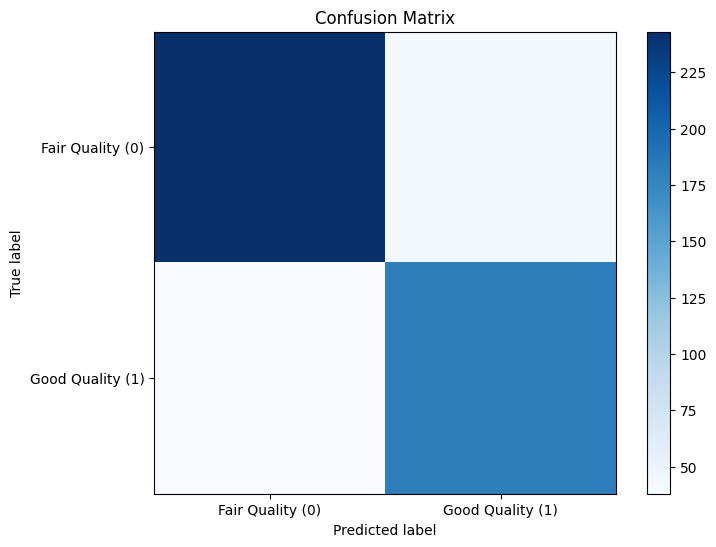

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Set up cross-validation
kfold = StratifiedKFold(n_splits=5)

# Initialize variables to store results
resultsLR = []
namesLR = []

# Evaluate polynomial degrees from 1 to 4 with normalization
for degree in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    xcurrent = poly.fit_transform(xtrains)  # Transform the input features

    # Normalize the features
    scaler = StandardScaler()
    xcurrent_normalized = scaler.fit_transform(xcurrent)  # Normalize the polynomial features

    # Initialize the Logistic Regression model
    model = LogisticRegression(max_iter=1000)

    # Perform cross-validation with normalized features
    cv_results_normalized = cross_val_score(model, xcurrent_normalized, ytrain, cv=kfold, scoring='accuracy')

    # Store the results
    resultsLR.append(cv_results_normalized)
    namesLR.append(f'{degree} (Normalized)')

    # Print the results for each degree
    print('%s-degree Polynomial (Normalized): Mean Accuracy: %f (%f)' % (degree, cv_results_normalized.mean(), cv_results_normalized.std()))

# Now evaluate polynomial degrees from 1 to 4 without normalization
for degree in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    xcurrent = poly.fit_transform(xtrains)  # Transform the input features

    # Initialize the Logistic Regression model
    model = LogisticRegression(max_iter=1000)

    # Perform cross-validation without normalization
    cv_results = cross_val_score(model, xcurrent, ytrain, cv=kfold, scoring='accuracy')

    # Store the results
    resultsLR.append(cv_results)
    namesLR.append(f'{degree} (No Normalization)')

    # Print the results for each degree
    print('%s-degree Polynomial (No Norm): Mean Accuracy: %f (%f)' % (degree, cv_results.mean(), cv_results.std()))

# Choose the best degree based on previous results; for example, let's assume it's degree 2
best_degree = 2

# Transform the training data with the best polynomial degree
poly = PolynomialFeatures(degree=best_degree)
xtrain_poly = poly.fit_transform(xtrains)

# Fit the model again with transformed features (with normalization)
scaler = StandardScaler()
xtrain_poly_normalized = scaler.fit_transform(xtrain_poly)  # Normalize the polynomial features

LR_best = LogisticRegression(max_iter=1000)
LR_best.fit(xtrain_poly_normalized, ytrain)

# Transform the validation data
xval_poly = poly.transform(xvals)
xval_poly_normalized = scaler.transform(xval_poly)  # Normalize the validation features

# Make predictions on the validation dataset
predictions = LR_best.predict(xval_poly_normalized)

# Calculate accuracy
accuracy = metrics.accuracy_score(yval, predictions)
print('Accuracy on validation set with best polynomial degree (%d): %f' % (best_degree, accuracy))

# Print confusion matrix
conf_matrix = metrics.confusion_matrix(yval, predictions)
print('Confusion Matrix:\n', conf_matrix)

# Optional: Visualizing the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
plt.yticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

Q5

Decision Tree (Normalized Features): Mean Accuracy: 0.855442, Std Dev: 0.008607
Accuracy on validation set (Normalized): 0.859127
Confusion Matrix (Normalized):
 [[245  40]
 [ 31 188]]


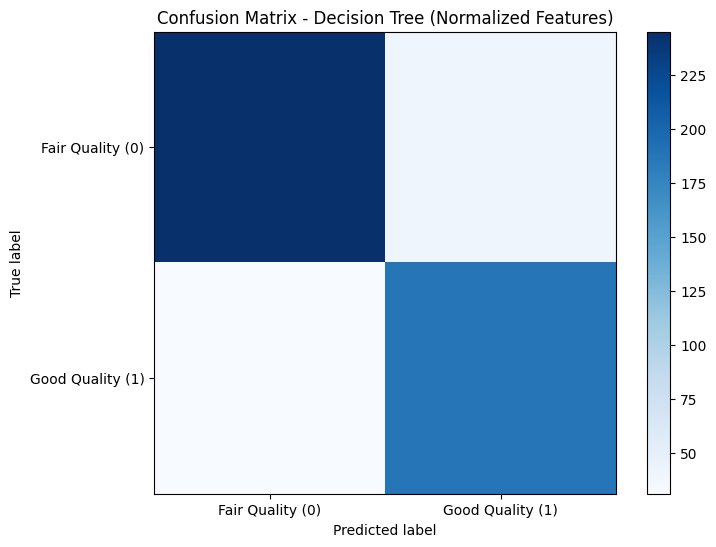

Decision Tree (Original Features): Mean Accuracy: 0.850971, Std Dev: 0.011295
Accuracy on validation set (Original): 0.561508
Confusion Matrix (Original):
 [[251  34]
 [187  32]]


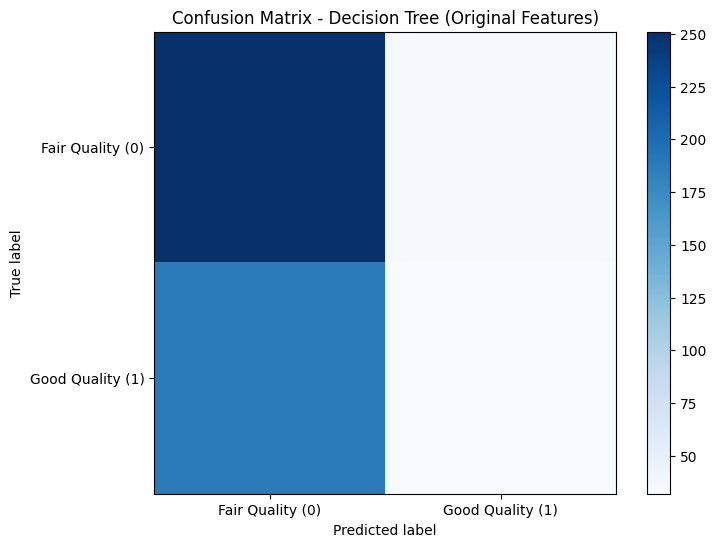

Random Forest (Normalized Features): Mean Accuracy: 0.906103, Std Dev: 0.010656
Accuracy on validation set (Normalized): 0.908730
Confusion Matrix (Normalized):
 [[261  24]
 [ 22 197]]


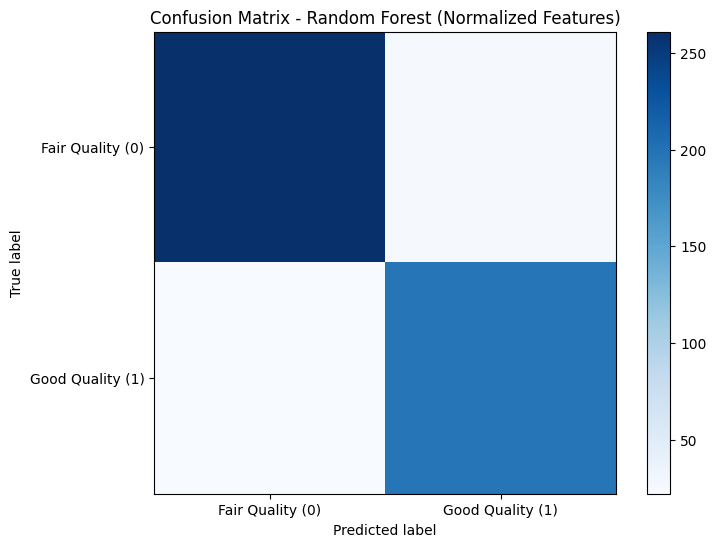

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Initialize the Decision Tree Classifier
DT = DecisionTreeClassifier()

# Set up cross-validation
kfold = StratifiedKFold(n_splits=5)

# Perform cross-validation with normalized features
cv_results_DT_norm = cross_val_score(DT, xtrains, ytrain, cv=kfold, scoring='accuracy')

# Fit the model on the normalized training data and evaluate on validation data
DT.fit(xtrains, ytrain)
predictions_DT_norm = DT.predict(xvals)

# Calculate accuracy and confusion matrix for normalized features
accuracy_DT_norm = metrics.accuracy_score(yval, predictions_DT_norm)
conf_matrix_DT_norm = metrics.confusion_matrix(yval, predictions_DT_norm)

print('Decision Tree (Normalized Features): Mean Accuracy: %f, Std Dev: %f' % (cv_results_DT_norm.mean(), cv_results_DT_norm.std()))
print('Accuracy on validation set (Normalized): %f' % accuracy_DT_norm)
print('Confusion Matrix (Normalized):\n', conf_matrix_DT_norm)

# Optional: Visualizing the confusion matrix for normalized features
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix_DT_norm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Decision Tree (Normalized Features)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
plt.yticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# Perform cross-validation with original features
cv_results_DT_orig = cross_val_score(DT, xtrain, ytrain, cv=kfold, scoring='accuracy')

# Fit the model on the original training data and evaluate on validation data
DT.fit(xtrain, ytrain)
predictions_DT_orig = DT.predict(xvals)

# Calculate accuracy and confusion matrix for original features
accuracy_DT_orig = metrics.accuracy_score(yval, predictions_DT_orig)
conf_matrix_DT_orig = metrics.confusion_matrix(yval, predictions_DT_orig)

print('Decision Tree (Original Features): Mean Accuracy: %f, Std Dev: %f' % (cv_results_DT_orig.mean(), cv_results_DT_orig.std()))
print('Accuracy on validation set (Original): %f' % accuracy_DT_orig)
print('Confusion Matrix (Original):\n', conf_matrix_DT_orig)

# Optional: Visualizing the confusion matrix for original features
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix_DT_orig, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Decision Tree (Original Features)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
plt.yticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# Initialize the Random Forest Classifier
RF = RandomForestClassifier()

# Perform cross-validation with normalized features
cv_results_RF_norm = cross_val_score(RF, xtrains, ytrain, cv=kfold, scoring='accuracy')

# Fit the model on the normalized training data and evaluate on validation data
RF.fit(xtrains, ytrain)
predictions_RF_norm = RF.predict(xvals)

# Calculate accuracy and confusion matrix for normalized features
accuracy_RF_norm = metrics.accuracy_score(yval, predictions_RF_norm)
conf_matrix_RF_norm = metrics.confusion_matrix(yval, predictions_RF_norm)

print('Random Forest (Normalized Features): Mean Accuracy: %f, Std Dev: %f' % (cv_results_RF_norm.mean(), cv_results_RF_norm.std()))
print('Accuracy on validation set (Normalized): %f' % accuracy_RF_norm)
print('Confusion Matrix (Normalized):\n', conf_matrix_RF_norm)

# Optional: Visualizing the confusion matrix for Random Forest (normalized features)
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix_RF_norm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Random Forest (Normalized Features)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
plt.yticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

Decision Tree (Normalized Features): Mean Accuracy: 0.857416, Std Dev: 0.014034
Accuracy on validation set (Normalized): 0.859127
Decision Tree (Original Features): Mean Accuracy: 0.854442, Std Dev: 0.013700
Accuracy on validation set (Original): 0.859127
Random Forest (Normalized Features): Mean Accuracy: 0.900644, Std Dev: 0.014844
Accuracy on validation set (Normalized): 0.914683
Random Forest (Original Features): Mean Accuracy: 0.905603, Std Dev: 0.012254
Accuracy on validation set (Original): 0.918651


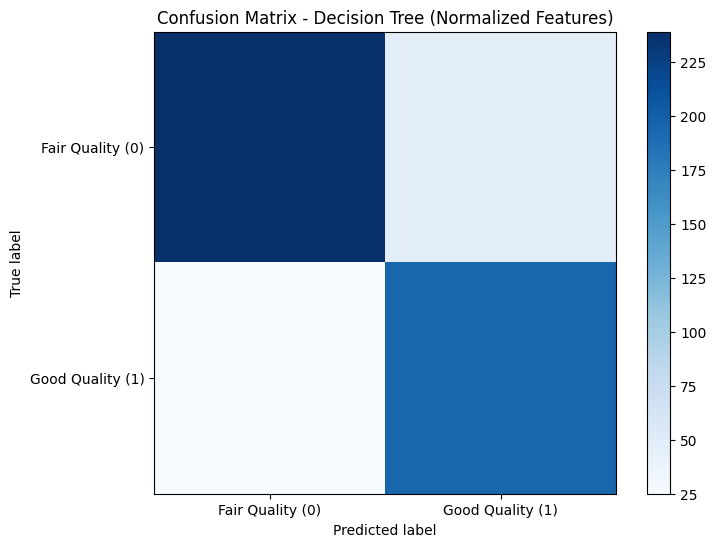

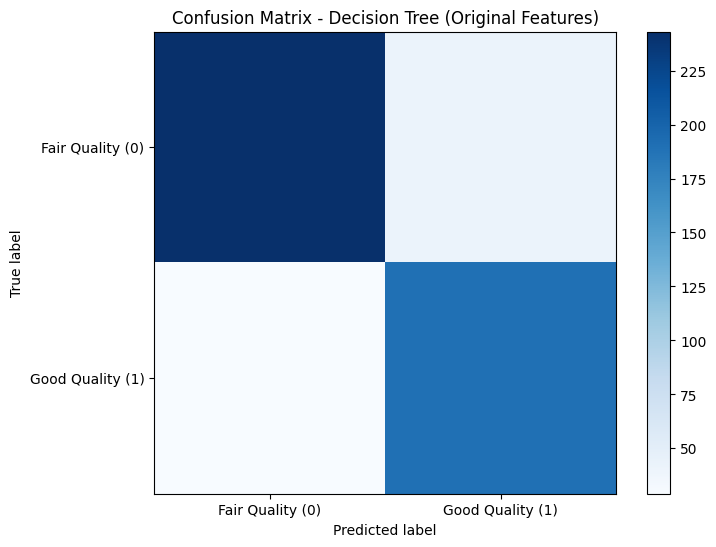

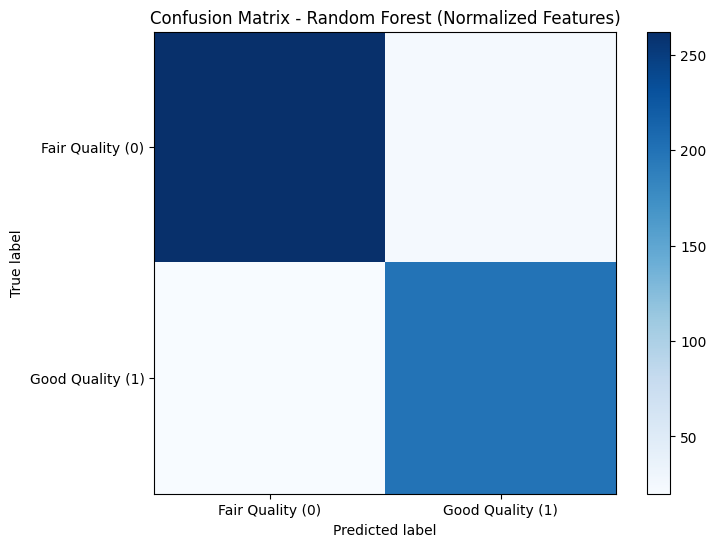

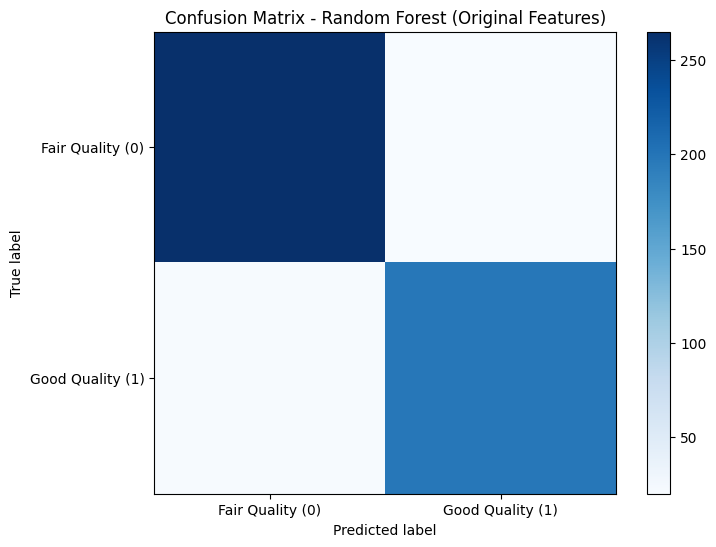

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Initialize classifiers
DT = DecisionTreeClassifier()
RF = RandomForestClassifier()

# Set up cross-validation
kfold = StratifiedKFold(n_splits=5)

# Normalize the training data
scaler = StandardScaler()
xtrains_normalized = scaler.fit_transform(xtrains)  # Normalize training features
xvals_normalized = scaler.transform(xvals)  # Normalize validation features

# Function to perform cross-validation and return results
def evaluate_model(model, x_train, y_train, x_val, y_val):
    cv_results = cross_val_score(model, x_train, y_train, cv=kfold, scoring='accuracy')
    model.fit(x_train, y_train)
    predictions = model.predict(x_val)
    accuracy = metrics.accuracy_score(y_val, predictions)
    return cv_results, accuracy, predictions

# Evaluate Decision Tree with Normalized Features
cv_results_DT_norm, accuracy_DT_norm, predictions_DT_norm = evaluate_model(DT, xtrains_normalized, ytrain, xvals_normalized, yval)

# Evaluate Decision Tree with Original Features
cv_results_DT_orig, accuracy_DT_orig, predictions_DT_orig = evaluate_model(DT, xtrains, ytrain, xvals, yval)

# Evaluate Random Forest with Normalized Features
cv_results_RF_norm, accuracy_RF_norm, predictions_RF_norm = evaluate_model(RF, xtrains_normalized, ytrain, xvals_normalized, yval)

# Evaluate Random Forest with Original Features
cv_results_RF_orig, accuracy_RF_orig, predictions_RF_orig = evaluate_model(RF, xtrains, ytrain, xvals, yval)

# Print results
print('Decision Tree (Normalized Features): Mean Accuracy: %f, Std Dev: %f' % (cv_results_DT_norm.mean(), cv_results_DT_norm.std()))
print('Accuracy on validation set (Normalized): %f' % accuracy_DT_norm)
print('Decision Tree (Original Features): Mean Accuracy: %f, Std Dev: %f' % (cv_results_DT_orig.mean(), cv_results_DT_orig.std()))
print('Accuracy on validation set (Original): %f' % accuracy_DT_orig)

print('Random Forest (Normalized Features): Mean Accuracy: %f, Std Dev: %f' % (cv_results_RF_norm.mean(), cv_results_RF_norm.std()))
print('Accuracy on validation set (Normalized): %f' % accuracy_RF_norm)
print('Random Forest (Original Features): Mean Accuracy: %f, Std Dev: %f' % (cv_results_RF_orig.mean(), cv_results_RF_orig.std()))
print('Accuracy on validation set (Original): %f' % accuracy_RF_orig)

# Optional: Visualizing confusion matrices
def plot_confusion_matrix(conf_matrix, title):
    plt.figure(figsize=(8, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
    plt.yticks(tick_marks, ['Fair Quality (0)', 'Good Quality (1)'])
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Confusion matrices
conf_matrix_DT_norm = metrics.confusion_matrix(yval, predictions_DT_norm)
conf_matrix_DT_orig = metrics.confusion_matrix(yval, predictions_DT_orig)
conf_matrix_RF_norm = metrics.confusion_matrix(yval, predictions_RF_norm)
conf_matrix_RF_orig = metrics.confusion_matrix(yval, predictions_RF_orig)

# Plotting confusion matrices
plot_confusion_matrix(conf_matrix_DT_norm, 'Confusion Matrix - Decision Tree (Normalized Features)')
plot_confusion_matrix(conf_matrix_DT_orig, 'Confusion Matrix - Decision Tree (Original Features)')
plot_confusion_matrix(conf_matrix_RF_norm, 'Confusion Matrix - Random Forest (Normalized Features)')
plot_confusion_matrix(conf_matrix_RF_orig, 'Confusion Matrix - Random Forest (Original Features)')

Q6

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Define the range of C values
C_values = [0.01, 0.1, 1, 5, 10]

# Initialize lists to store the models
modelsSVM = []

# Create models for linear and RBF kernels
for C in C_values:
    modelsSVM.append(('Linear C=' + str(C), SVC(kernel='linear', C=C)))
    modelsSVM.append(('RBF C=' + str(C), SVC(kernel='rbf', C=C)))

# Set up cross-validation
kfold = StratifiedKFold(n_splits=5)

# Initialize lists to store results
resultSVM = []
nameSVM = []

# Evaluate each model using cross-validation
for name, model in modelsSVM:
    cv_results = cross_val_score(model, xtrains, ytrain, cv=kfold, scoring='accuracy')
    resultSVM.append(cv_results)
    nameSVM.append(name)
    print('%s: Mean Accuracy: %f, Std Dev: %f' % (name, cv_results.mean(), cv_results.std()))

# Assuming the best C for linear kernel is found to be 1 and for RBF kernel is found to be 10
best_C_linear = 1  # Replace with your best value
best_C_rbf = 10    # Replace with your best value

# Linear Kernel
model_linear = SVC(kernel='linear', C=best_C_linear)
model_linear.fit(xtrains, ytrain)
predictions_linear = model_linear.predict(xvals)

# RBF Kernel
model_rbf = SVC(kernel='rbf', C=best_C_rbf)
model_rbf.fit(xtrains, ytrain)
predictions_rbf = model_rbf.predict(xvals)

# Calculate accuracy and confusion matrix for both models
accuracy_linear = metrics.accuracy_score(yval, predictions_linear)
conf_matrix_linear = metrics.confusion_matrix(yval, predictions_linear)

accuracy_rbf = metrics.accuracy_score(yval, predictions_rbf)
conf_matrix_rbf = metrics.confusion_matrix(yval, predictions_rbf)

print('Linear Kernel Accuracy: %f' % accuracy_linear)
print('Linear Kernel Confusion Matrix:\n', conf_matrix_linear)

print('RBF Kernel Accuracy: %f' % accuracy_rbf)
print('RBF Kernel Confusion Matrix:\n', conf_matrix_rbf)

# Fit and predict using original features for linear kernel
model_linear_original = SVC(kernel='linear', C=best_C_linear)
model_linear_original.fit(xtrain, ytrain)
predictions_linear_original = model_linear_original.predict(xval)

# Calculate accuracy and confusion matrix
accuracy_linear_original = metrics.accuracy_score(yval, predictions_linear_original)
conf_matrix_linear_original = metrics.confusion_matrix(yval, predictions_linear_original)

print('Linear Kernel Accuracy (Original Features): %f' % accuracy_linear_original)
print('Linear Kernel Confusion Matrix (Original Features):\n', conf_matrix_linear_original)

# Fit and predict using original features for RBF kernel
model_rbf_original = SVC(kernel='rbf', C=best_C_rbf)
model_rbf_original.fit(xtrain, ytrain)
predictions_rbf_original = model_rbf_original.predict(xval)

# Calculate accuracy and confusion matrix
accuracy_rbf_original = metrics.accuracy_score(yval, predictions_rbf_original)
conf_matrix_rbf_original = metrics.confusion_matrix(yval, predictions_rbf_original)

print('RBF Kernel Accuracy (Original Features): %f' % accuracy_rbf_original)
print('RBF Kernel Confusion Matrix (Original Features):\n', conf_matrix_rbf_original)

Linear C=0.01: Mean Accuracy: 0.824139, Std Dev: 0.022671
RBF C=0.01: Mean Accuracy: 0.739697, Std Dev: 0.017357
Linear C=0.1: Mean Accuracy: 0.826124, Std Dev: 0.022331
RBF C=0.1: Mean Accuracy: 0.839537, Std Dev: 0.018557
Linear C=1: Mean Accuracy: 0.825631, Std Dev: 0.020299
RBF C=1: Mean Accuracy: 0.867848, Std Dev: 0.009756
Linear C=5: Mean Accuracy: 0.826129, Std Dev: 0.022407
RBF C=5: Mean Accuracy: 0.875793, Std Dev: 0.012992
Linear C=10: Mean Accuracy: 0.826626, Std Dev: 0.023022
RBF C=10: Mean Accuracy: 0.876300, Std Dev: 0.007171
Linear Kernel Accuracy: 0.811508
Linear Kernel Confusion Matrix:
 [[240  45]
 [ 50 169]]
RBF Kernel Accuracy: 0.880952
RBF Kernel Confusion Matrix:
 [[250  35]
 [ 25 194]]
Linear Kernel Accuracy (Original Features): 0.815476
Linear Kernel Confusion Matrix (Original Features):
 [[239  46]
 [ 47 172]]
RBF Kernel Accuracy (Original Features): 0.823413
RBF Kernel Confusion Matrix (Original Features):
 [[257  28]
 [ 61 158]]


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Define the range of C values
C_values = [0.01, 0.1, 1, 5, 10]

# Initialize lists to store the models
modelsSVM = []

# Create models for linear and RBF kernels
for C in C_values:
    modelsSVM.append(('Linear C=' + str(C), SVC(kernel='linear', C=C)))
    modelsSVM.append(('RBF C=' + str(C), SVC(kernel='rbf', C=C)))

# Set up cross-validation
kfold = StratifiedKFold(n_splits=5)

# Normalize the training data
scaler = StandardScaler()
xtrains_normalized = scaler.fit_transform(xtrains)  # Normalize training features
xvals_normalized = scaler.transform(xvals)  # Normalize validation features

# Initialize lists to store results
resultSVM_norm = []
resultSVM_orig = []
nameSVM = []

# Evaluate each model using cross-validation (normalized features)
for name, model in modelsSVM:
    cv_results = cross_val_score(model, xtrains_normalized, ytrain, cv=kfold, scoring='accuracy')
    resultSVM_norm.append(cv_results)
    print('%s (Normalized Features): Mean Accuracy: %f, Std Dev: %f' % (name, cv_results.mean(), cv_results.std()))

# Evaluate each model using cross-validation (original features)
for name, model in modelsSVM:
    cv_results = cross_val_score(model, xtrains, ytrain, cv=kfold, scoring='accuracy')
    resultSVM_orig.append(cv_results)
    print('%s (Original Features): Mean Accuracy: %f, Std Dev: %f' % (name, cv_results.mean(), cv_results.std()))

# Assuming the best C for linear kernel is found to be 1 and for RBF kernel is found to be 10
best_C_linear = 1  # Replace with your best value
best_C_rbf = 10    # Replace with your best value

# Linear Kernel with Normalized Features
model_linear = SVC(kernel='linear', C=best_C_linear)
model_linear.fit(xtrains_normalized, ytrain)
predictions_linear = model_linear.predict(xvals_normalized)

# RBF Kernel with Normalized Features
model_rbf = SVC(kernel='rbf', C=best_C_rbf)
model_rbf.fit(xtrains_normalized, ytrain)
predictions_rbf = model_rbf.predict(xvals_normalized)

# Calculate accuracy and confusion matrix for both models (Normalized)
accuracy_linear = metrics.accuracy_score(yval, predictions_linear)
conf_matrix_linear = metrics.confusion_matrix(yval, predictions_linear)

accuracy_rbf = metrics.accuracy_score(yval, predictions_rbf)
conf_matrix_rbf = metrics.confusion_matrix(yval, predictions_rbf)

print('Linear Kernel Accuracy (Normalized Features): %f' % accuracy_linear)
print('Linear Kernel Confusion Matrix (Normalized Features):\n', conf_matrix_linear)

print('RBF Kernel Accuracy (Normalized Features): %f' % accuracy_rbf)
print('RBF Kernel Confusion Matrix (Normalized Features):\n', conf_matrix_rbf)

# Fit and predict using original features for linear kernel
model_linear_original = SVC(kernel='linear', C=best_C_linear)
model_linear_original.fit(xtrains, ytrain)
predictions_linear_original = model_linear_original.predict(xvals)

# Calculate accuracy and confusion matrix (Original Features)
accuracy_linear_original = metrics.accuracy_score(yval, predictions_linear_original)
conf_matrix_linear_original = metrics.confusion_matrix(yval, predictions_linear_original)

print('Linear Kernel Accuracy (Original Features): %f' % accuracy_linear_original)
print('Linear Kernel Confusion Matrix (Original Features):\n', conf_matrix_linear_original)

# Fit and predict using original features for RBF kernel
model_rbf_original = SVC(kernel='rbf', C=best_C_rbf)
model_rbf_original.fit(xtrains, ytrain)
predictions_rbf_original = model_rbf_original.predict(xvals)

# Calculate accuracy and confusion matrix (Original Features)
accuracy_rbf_original = metrics.accuracy_score(yval, predictions_rbf_original)
conf_matrix_rbf_original = metrics.confusion_matrix(yval, predictions_rbf_original)

print('RBF Kernel Accuracy (Original Features): %f' % accuracy_rbf_original)
print('RBF Kernel Confusion Matrix (Original Features):\n', conf_matrix_rbf_original)

Linear C=0.01 (Normalized Features): Mean Accuracy: 0.824139, Std Dev: 0.022671
RBF C=0.01 (Normalized Features): Mean Accuracy: 0.739697, Std Dev: 0.017357
Linear C=0.1 (Normalized Features): Mean Accuracy: 0.826124, Std Dev: 0.022331
RBF C=0.1 (Normalized Features): Mean Accuracy: 0.839537, Std Dev: 0.018557
Linear C=1 (Normalized Features): Mean Accuracy: 0.825631, Std Dev: 0.020299
RBF C=1 (Normalized Features): Mean Accuracy: 0.867848, Std Dev: 0.009756
Linear C=5 (Normalized Features): Mean Accuracy: 0.826129, Std Dev: 0.022407
RBF C=5 (Normalized Features): Mean Accuracy: 0.875793, Std Dev: 0.012992
Linear C=10 (Normalized Features): Mean Accuracy: 0.826626, Std Dev: 0.023022
RBF C=10 (Normalized Features): Mean Accuracy: 0.876300, Std Dev: 0.007171
Linear C=0.01 (Original Features): Mean Accuracy: 0.824139, Std Dev: 0.022671
RBF C=0.01 (Original Features): Mean Accuracy: 0.739697, Std Dev: 0.017357
Linear C=0.1 (Original Features): Mean Accuracy: 0.826124, Std Dev: 0.022331
RBF

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris  # Example dataset

# Load example dataset (replace with your own data)
data = load_iris()
X, y = data.data, data.target

# Initialize models for both normalization and non-normalization
modelsSVM = []
params = [0.01, 0.1, 1, 5, 10]

# Add Linear and RBF models
for C in params:
    modelsSVM.append(('Linear C=' + str(C), SVC(kernel='linear', C=C)))
    modelsSVM.append(('RBF C=' + str(C), SVC(kernel='rbf', C=C)))

# Cross-validation setup
kfold = StratifiedKFold(n_splits=5)

# Result storage
resultSVM = []
nameSVM = []

# Evaluation without normalization
print("No Normalization Results:")
for name, model in modelsSVM:
    cv_results = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    resultSVM.append(cv_results)
    nameSVM.append(name)
    print('%s: Mean Accuracy: %f, Std Dev: %f' % (name, cv_results.mean(), cv_results.std()))

# Normalization using StandardScaler
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Clear results for normalized evaluation
resultSVM_normalized = []
nameSVM_normalized = []

# Evaluation with normalization
print("\nWith Normalization Results:")
for name, model in modelsSVM:
    cv_results = cross_val_score(model, X_normalized, y, cv=kfold, scoring='accuracy')
    resultSVM_normalized.append(cv_results)
    nameSVM_normalized.append(name)
    print('%s: Mean Accuracy: %f, Std Dev: %f' % (name, cv_results.mean(), cv_results.std()))

No Normalization Results:
Linear C=0.01: Mean Accuracy: 0.920000, Std Dev: 0.040000
RBF C=0.01: Mean Accuracy: 0.926667, Std Dev: 0.024944
Linear C=0.1: Mean Accuracy: 0.973333, Std Dev: 0.013333
RBF C=0.1: Mean Accuracy: 0.920000, Std Dev: 0.026667
Linear C=1: Mean Accuracy: 0.980000, Std Dev: 0.016330
RBF C=1: Mean Accuracy: 0.966667, Std Dev: 0.021082
Linear C=5: Mean Accuracy: 0.980000, Std Dev: 0.026667
RBF C=5: Mean Accuracy: 0.986667, Std Dev: 0.016330
Linear C=10: Mean Accuracy: 0.973333, Std Dev: 0.038873
RBF C=10: Mean Accuracy: 0.980000, Std Dev: 0.016330

With Normalization Results:
Linear C=0.01: Mean Accuracy: 0.880000, Std Dev: 0.045216
RBF C=0.01: Mean Accuracy: 0.880000, Std Dev: 0.049889
Linear C=0.1: Mean Accuracy: 0.966667, Std Dev: 0.021082
RBF C=0.1: Mean Accuracy: 0.900000, Std Dev: 0.029814
Linear C=1: Mean Accuracy: 0.966667, Std Dev: 0.029814
RBF C=1: Mean Accuracy: 0.966667, Std Dev: 0.021082
Linear C=5: Mean Accuracy: 0.966667, Std Dev: 0.036515
RBF C=5: Mea